# 05 · Interpretabilidad (SHAP)

SHAP reparte la predicción de cada reclamación entre sus variables (positivo = empuja hacia fraude). Se calcula sobre test.

In [1]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from src.preprocesamiento import COLUMNAS

test = pd.read_csv('../data/processed/test.csv')
modelo = joblib.load('../models/modelo_con_fault.joblib')
preprocesador, lgbm = modelo[0], modelo[-1]

X = pd.DataFrame(preprocesador.transform(test[COLUMNAS]), columns=preprocesador.get_feature_names_out())
shap_valores = shap.TreeExplainer(lgbm)(X)
X.shape

(3084, 64)

## 1. Qué variables usa más el modelo

Efecto medio absoluto por variable original.

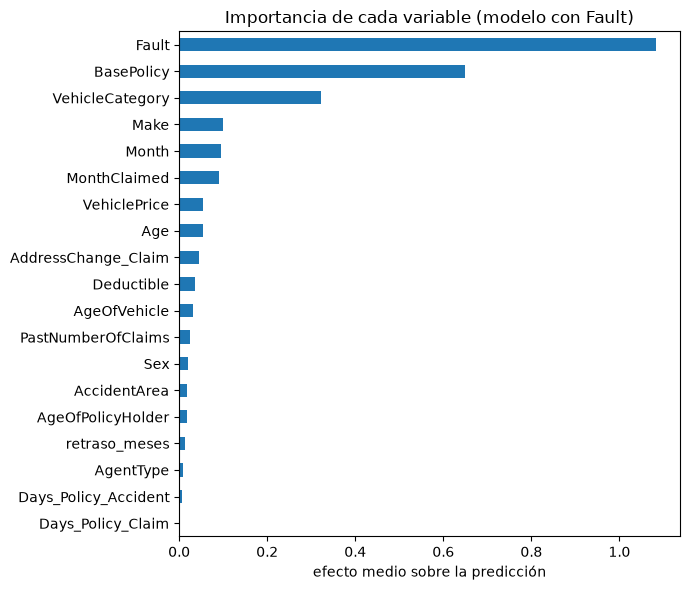

In [2]:
def variable_original(columna):
    transformador, nombre = columna.split('__', 1)
    if transformador != 'nominales':
        return nombre
    return next(c for c in COLUMNAS if nombre.startswith(c + '_'))

def importancia(valores, columnas):
    efecto = pd.DataFrame(np.abs(valores), columns=[variable_original(c) for c in columnas])
    return efecto.T.groupby(level=0).sum().T.mean().sort_values()

imp_con = importancia(shap_valores.values, X.columns)

imp_con.plot.barh(figsize=(7, 6), title='Importancia de cada variable (modelo con Fault)')
plt.xlabel('efecto medio sobre la predicción')
plt.tight_layout()
plt.savefig('../reports/figures/importancia_variables.png', dpi=120)
plt.show()

Tres variables concentran casi toda la decisión: Fault, BasePolicy y VehicleCategory, en línea con la ablación del notebook 03.

## 2. En qué dirección empuja cada variable

Cada punto es una reclamación; rojo = valor alto; derecha = hacia fraude.

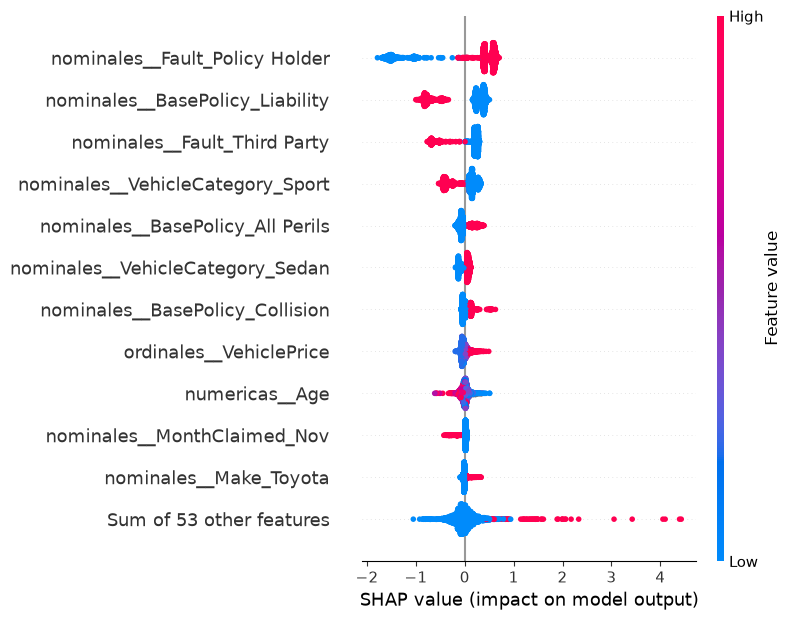

In [3]:
shap.plots.beeswarm(shap_valores, max_display=12, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/direccion_variables.png', dpi=120)
plt.show()

Tasa real de fraude en test de las categorías que más pesan:

In [4]:
for c in ['Fault', 'BasePolicy', 'VehicleCategory']:
    print(test.groupby(c)['FraudFound_P'].agg(n='size', tasa_fraude='mean').round(3))
    print()

                  n  tasa_fraude
Fault                           
Policy Holder  2265        0.079
Third Party     819        0.006

               n  tasa_fraude
BasePolicy                   
All Perils   878        0.105
Collision   1163        0.076
Liability   1043        0.005

                    n  tasa_fraude
VehicleCategory                   
Sedan            1909        0.084
Sport            1108        0.016
Utility            67        0.090



La culpa del asegurado empuja hacia fraude (7,9 % frente a 0,6 % si es de un tercero). La cobertura Liability empuja hacia no fraude (0,5 %) y All Perils hacia fraude (10,5 %). Sport empuja hacia no fraude (1,6 %), pero coincide casi siempre con pólizas Liability, así que gran parte de su efecto es el de la cobertura.

## 3. Casos concretos

### 3.1 Reclamación con mayor probabilidad de fraude

In [5]:
prob = modelo.predict_proba(test[COLUMNAS])[:, 1]
test['probabilidad'] = prob

i = int(np.argmax(prob))
print('Probabilidad:', round(prob[i], 3), '| ¿Era fraude?:', test.loc[i, 'FraudFound_P'])
test.loc[i, COLUMNAS]

Probabilidad: 0.845 | ¿Era fraude?: 1


AgeOfVehicle                    7 years
AgeOfPolicyHolder              36 to 40
VehiclePrice            less than 20000
PastNumberOfClaims               2 to 4
Days_Policy_Accident               none
Days_Policy_Claim          more than 30
Make                            Pontiac
AccidentArea                      Urban
Sex                                Male
Fault                       Third Party
VehicleCategory                   Sedan
BasePolicy                   All Perils
AgentType                      External
Deductible                          500
AddressChange_Claim        2 to 3 years
Month                               Dec
MonthClaimed                        Jan
Age                                41.0
retraso_meses                         1
Name: 1330, dtype: object

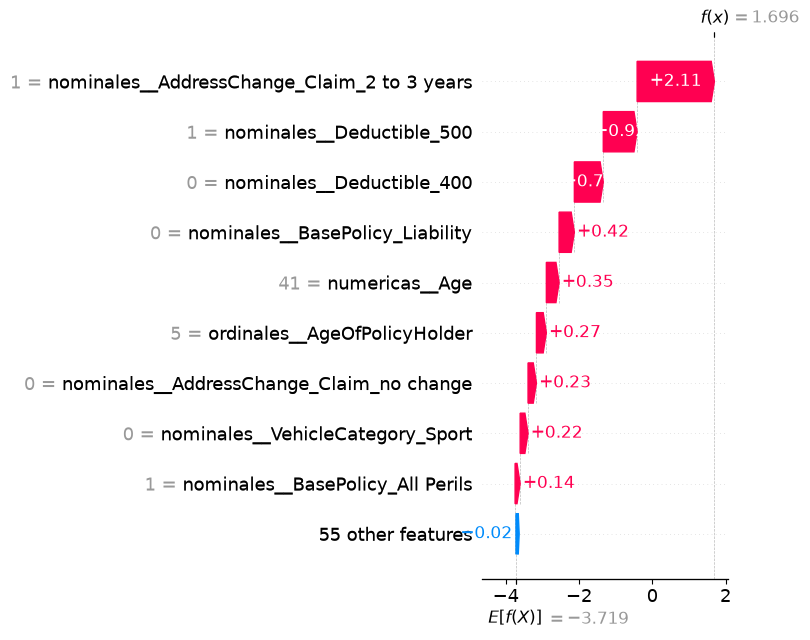

In [6]:
shap.plots.waterfall(shap_valores[i], max_display=10, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/caso_alto_riesgo.png', dpi=120, bbox_inches='tight')
plt.show()

Valores en escala log-odds: de −3,7 (≈ 2 %) a 1,7 (≈ 85 %). Aunque la culpa es de un tercero, la dispara un cambio de domicilio 2–3 años antes (17,5 % de fraude en el EDA), una franquicia de 500 (17,9 %) y la póliza todo riesgo. El modelo combina señales en vez de aplicar una sola regla.

### 3.2 Fraudes que el modelo no detecta

Fraudes de test con menor probabilidad.

In [7]:
fraudes = test[test['FraudFound_P'] == 1].sort_values('probabilidad')
print('Fraudes de test:', len(fraudes))
print('Con probabilidad < 2 %:', (fraudes['probabilidad'] < 0.02).sum())
fraudes.head(10)[['probabilidad', 'Fault', 'BasePolicy', 'VehicleCategory', 'Make', 'AgeOfPolicyHolder']]

Fraudes de test: 185
Con probabilidad < 2 %: 4


,probabilidad,Fault,BasePolicy,VehicleCategory,Make,AgeOfPolicyHolder
2868,0.008338,Policy Holder,Liability,Sport,Honda,41 to 50
975,0.009072,Policy Holder,Liability,Sport,Chevrolet,36 to 40
2401,0.010482,Policy Holder,Liability,Sport,Toyota,36 to 40
1862,0.016020,Policy Holder,Liability,Sport,Toyota,36 to 40
566,0.021082,Policy Holder,Liability,Sport,Acura,26 to 30
535,0.028979,Policy Holder,Collision,Sedan,VW,36 to 40
2028,0.034842,Policy Holder,Collision,Sedan,Honda,36 to 40
2927,0.043876,Policy Holder,Collision,Sedan,Toyota,31 to 35
1716,0.044475,Policy Holder,Collision,Sedan,Pontiac,36 to 40
16,0.048126,Policy Holder,All Perils,Sedan,VW,36 to 40


Son pólizas Liability, sobre todo con vehículo Sport: en esa cobertura el fraude es rarísimo (0,5 %) y el modelo la descarta. Aun así, solo 4 de los 185 fraudes de test tienen probabilidad inferior al 2 %.

## 4. Versión sin Fault

Importancia de las variables con y sin Fault.

In [8]:
modelo_sin = joblib.load('../models/modelo_sin_fault.joblib')
columnas_sin = [c for c in COLUMNAS if c != 'Fault']
X_sin = pd.DataFrame(modelo_sin[0].transform(test[columnas_sin]), columns=modelo_sin[0].get_feature_names_out())
imp_sin = importancia(shap.TreeExplainer(modelo_sin[-1])(X_sin).values, X_sin.columns)

pd.DataFrame({'con Fault': imp_con, 'sin Fault': imp_sin}).sort_values('con Fault', ascending=False).round(3)

,con Fault,sin Fault
Fault,1.083,NaN
BasePolicy,0.649,0.479
VehicleCategory,0.322,0.139
Make,0.099,0.026
Month,0.095,0.046
MonthClaimed,0.090,0.049
VehiclePrice,0.054,0.027
Age,0.053,0.025
AddressChange_Claim,0.046,0.017
Deductible,0.036,0.020


Sin Fault el modelo se apoya en las mismas variables, con menos fuerza; ninguna sustituye a la culpa, de ahí la caída de PR-AUC (0,257 → 0,150).

Conclusión: las reclamaciones con culpa del asegurado, cobertura todo riesgo o colisión y señales poco frecuentes (cambio de domicilio, franquicia alta) son las más sospechosas. El punto ciego son los fraudes en pólizas de solo responsabilidad civil.